In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.dates as mdates
import statsmodels.formula.api as smf

In [2]:
df = pd.read_excel('Project2Data.xls')
df_main = df.dropna(how='all') ## drop nan rows between data rows

## Data Pre-processing

In [3]:
## we notice there are 2 rows with nan values, and 0 in other values, seems like false data. Dropped
## See Lecture 6 slide 23: unbalanced data results in bias 
df_main[df_main.isna().any(axis=1)]
df_cleaned = df_main.dropna()
## Remove 10/03/2020 from ENGINE Phase 3 so that we have same dates in ENGINE vs UTOWN --> slide 23, unbalanced data will lead to bias
df_cleaned = df_cleaned.loc[df_cleaned['Date'] != '2020-03-10']

## We also notice that the dates in UTOWN and ENGINE are misaligned
## UTOWN has dates 2020-01-13 and 2020-01-14 not in ENGINE
## ENGINE has dates 2020-01-16 and 2020-02-07 not in UTOWN
## Both of which corresponds to phase 1 > we can safely drop them to create a balanced dataset (same dates for ENGINE and UTOWN in phase 1, 2 and 3)
df_engine = df_cleaned.loc[df_cleaned['Area'] == 'ENGINE'].copy()
df_utown = df_cleaned.loc[df_cleaned['Area'] == 'UTOWN'].copy()


dates_not_in = df_engine.merge(df_utown, on='Date', how='outer', indicator=True)
dates_not_in = dates_not_in.loc[dates_not_in['_merge'] != 'both']
for index,row in dates_not_in.iterrows():
    if row['_merge'] == 'right_only':
        print(f'UTOWN Unique Dates: {row['Date']}')
    else:
        print(f'ENGINE Unique Dates: {row['Date']}')

dates_to_remove = ['2020-01-13', '2020-01-14', '2020-01-16', '2020-02-7']
df_cleaned = df_cleaned[~df_cleaned['Date'].isin(dates_to_remove)]
df_cleaned

UTOWN Unique Dates: 2020-01-13 00:00:00
UTOWN Unique Dates: 2020-01-14 00:00:00
ENGINE Unique Dates: 2020-01-16 00:00:00
ENGINE Unique Dates: 2020-02-07 00:00:00


/var/folders/07/c85cb0wx64dctzstjkd9gmxc0000gn/T/ipykernel_11455/2824238974.py:25: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_cleaned = df_cleaned[~df_cleaned['Date'].isin(dates_to_remove)]


,Area,Date,PaperContaminant,PlasticContaminant,CanContaminant,FirstTrialPhase
2,ENGINE,2020-01-15,0.714286,35.340136,0.869565,1.0
8,ENGINE,2020-01-17,1.285714,50.483325,29.047619,1.0
11,ENGINE,2020-01-18,1.714286,47.214206,12.222222,1.0
14,ENGINE,2020-01-19,0.285714,44.444444,0.000000,1.0
17,ENGINE,2020-01-20,0.571429,44.409171,2.500000,1.0
...,...,...,...,...,...,...
242,UTOWN,2020-03-12,6.888889,55.657396,26.180556,3.0
245,UTOWN,2020-03-13,3.555556,56.030446,14.748299,3.0
248,UTOWN,2020-03-14,3.444444,61.640623,22.269166,3.0
251,UTOWN,2020-03-16,6.888889,55.657396,26.180556,3.0


## Lets visualise

#### First we plot scatter plot of each contaminant rate over time for engine and utown separately
We also get the mean and standard deviations of each contaminant during each phase in engine and in utown

------------- Phase 1 -------------
PaperContaminant mean = 0.85
PaperContaminant std = 0.40
PlasticContaminant mean = 48.35
PlasticContaminant std = 11.64
CanContaminant mean = 14.85
CanContaminant std = 9.31
------------- Phase 2 -------------
PaperContaminant mean = 1.29
PaperContaminant std = 2.04
PlasticContaminant mean = 35.96
PlasticContaminant std = 9.09
CanContaminant mean = 11.67
CanContaminant std = 9.66
------------- Phase 3 -------------
PaperContaminant mean = 0.77
PaperContaminant std = 1.41
PlasticContaminant mean = 39.39
PlasticContaminant std = 7.59
CanContaminant mean = 7.86
CanContaminant std = 8.27


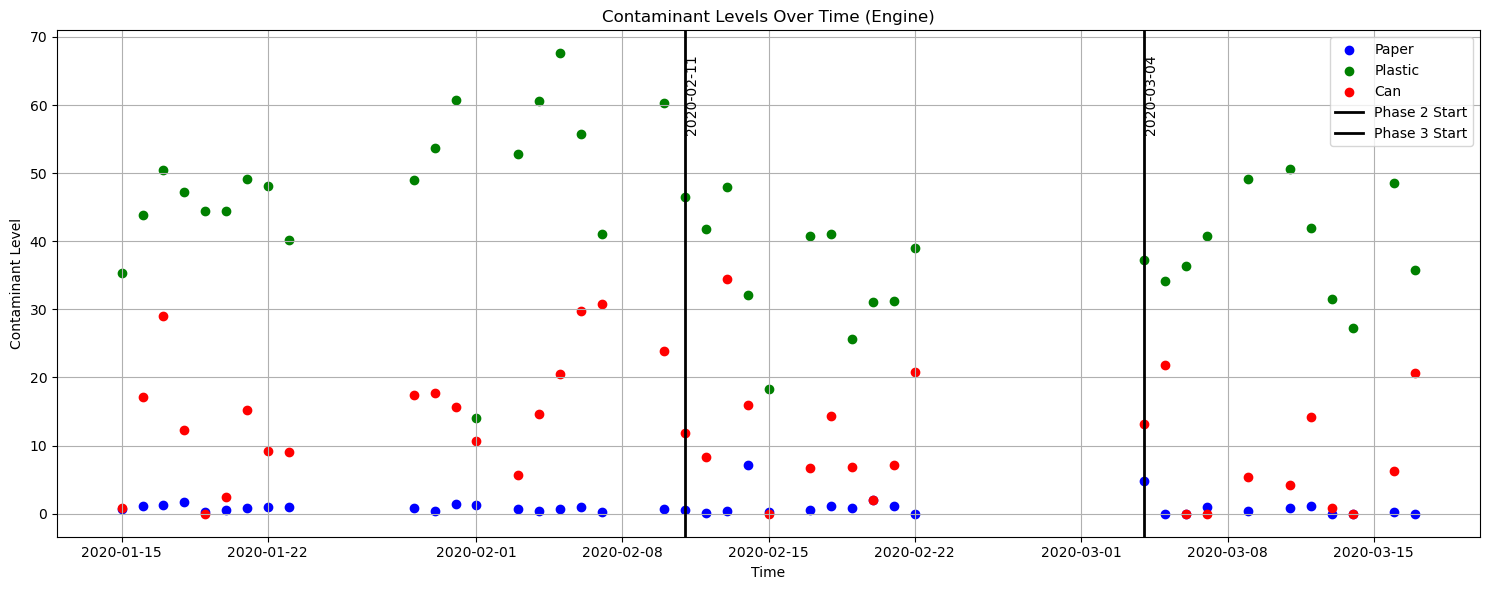

In [4]:
time_col = 'Date' 
paper_col = 'PaperContaminant'     
plastic_col = 'PlasticContaminant'   
can_col = 'CanContaminant' 

# Get phase start dates
phase2_start = df_engine.loc[df_engine['FirstTrialPhase'] == 2]['Date'].iloc[0]
phase3_start = df_engine.loc[df_engine['FirstTrialPhase'] == 3]['Date'].iloc[0]

# Get mean and std of each contaminant type at each phase in engine
phase1_df_engine = df_engine.loc[df_engine['FirstTrialPhase'] == 1]
phase2_df_engine = df_engine.loc[df_engine['FirstTrialPhase'] == 2]
phase3_df_engine = df_engine.loc[df_engine['FirstTrialPhase'] == 3]

for index, phase in enumerate([phase1_df_engine, phase2_df_engine, phase3_df_engine]):
    print(f"------------- Phase {index + 1} -------------")
    for typecontaminant in ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']:

        mean = phase[typecontaminant].mean()
        std = phase[typecontaminant].std()
        print(f"{typecontaminant} mean = {mean:.2f}")
        print(f"{typecontaminant} std = {std:.2f}")

# Plot scatter graph
plt.figure(figsize=(15, 6))
plt.scatter(df_engine[time_col], df_engine[paper_col], color='blue', label='Paper')
plt.scatter(df_engine[time_col], df_engine[plastic_col], color='green', label='Plastic')
plt.scatter(df_engine[time_col], df_engine[can_col], color='red', label='Can')

# Add vertical lines for phase starts
plt.axvline(pd.to_datetime(phase2_start), color='black', linestyle='-', linewidth=2, label='Phase 2 Start')
plt.axvline(pd.to_datetime(phase3_start), color='black', linestyle='-', linewidth=2, label='Phase 3 Start')

plt.text(pd.to_datetime(phase2_start), plt.ylim()[1]*0.95, f'{phase2_start.date()}', rotation=90, color='black', va='top')
plt.text(pd.to_datetime(phase3_start), plt.ylim()[1]*0.95, f'{phase3_start.date()}', rotation=90, color='black', va='top')


# Plot graph
plt.title('Contaminant Levels Over Time (Engine)')
plt.xlabel('Time')
plt.ylabel('Contaminant Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

------------- Phase 1 -------------
PaperContaminant mean = 6.36
PaperContaminant std = 3.56
PlasticContaminant mean = 60.30
PlasticContaminant std = 7.08
CanContaminant mean = 36.47
CanContaminant std = 10.19
------------- Phase 2 -------------
PaperContaminant mean = 4.00
PaperContaminant std = 1.48
PlasticContaminant mean = 46.51
PlasticContaminant std = 7.23
CanContaminant mean = 18.34
CanContaminant std = 10.18
------------- Phase 3 -------------
PaperContaminant mean = 4.69
PaperContaminant std = 1.77
PlasticContaminant mean = 59.18
PlasticContaminant std = 3.52
CanContaminant mean = 22.31
CanContaminant std = 5.11


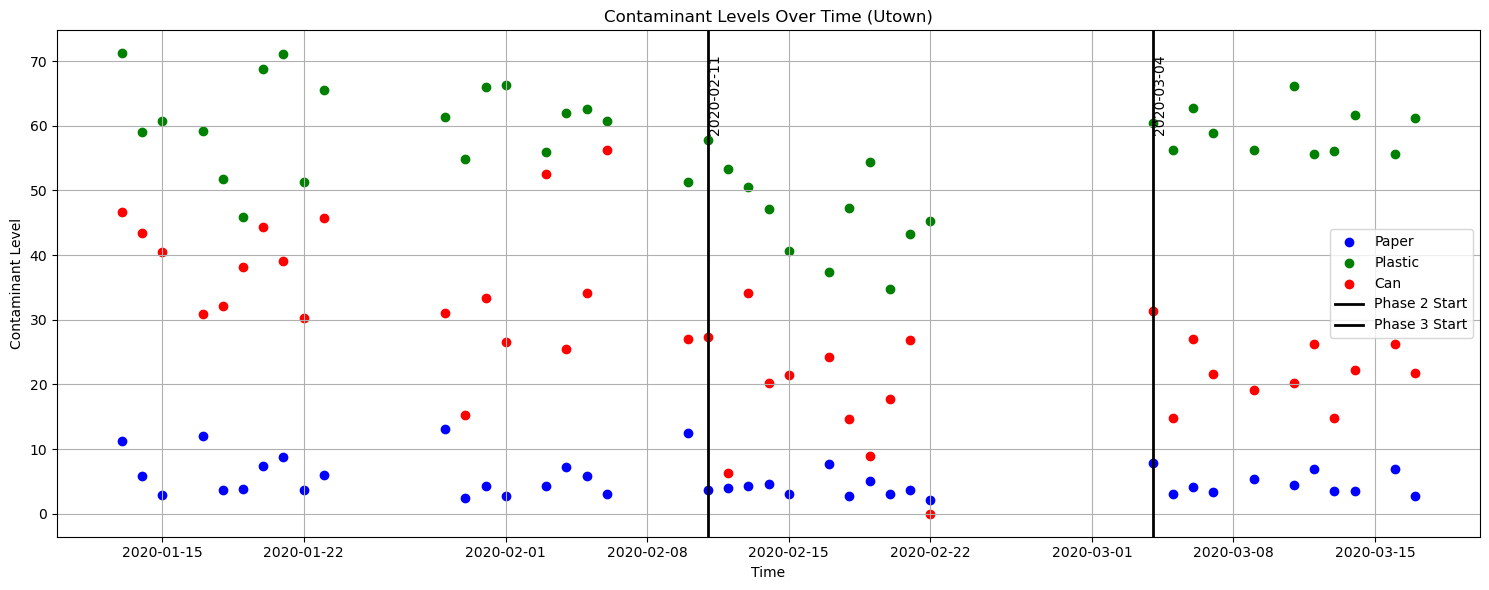

In [5]:
time_col = 'Date' 
paper_col = 'PaperContaminant'     
plastic_col = 'PlasticContaminant'   
can_col = 'CanContaminant' 

# Get phase start dates
phase2_start = df_utown.loc[df_utown['FirstTrialPhase'] == 2]['Date'].iloc[0]
phase3_start = df_utown.loc[df_utown['FirstTrialPhase'] == 3]['Date'].iloc[0]

# Get mean and std of each contaminant type at each phase in engine
phase1_df_utown = df_utown.loc[df_utown['FirstTrialPhase'] == 1]
phase2_df_utown = df_utown.loc[df_utown['FirstTrialPhase'] == 2]
phase3_df_utown = df_utown.loc[df_utown['FirstTrialPhase'] == 3]

for index, phase in enumerate([phase1_df_utown, phase2_df_utown, phase3_df_utown]):
    print(f"------------- Phase {index + 1} -------------")
    for typecontaminant in ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']:

        mean = phase[typecontaminant].mean()
        std = phase[typecontaminant].std()
        print(f"{typecontaminant} mean = {mean:.2f}")
        print(f"{typecontaminant} std = {std:.2f}")

# Plot scatter graph
plt.figure(figsize=(15, 6))
plt.scatter(df_utown[time_col], df_utown[paper_col], color='blue', label='Paper')
plt.scatter(df_utown[time_col], df_utown[plastic_col], color='green', label='Plastic')
plt.scatter(df_utown[time_col], df_utown[can_col], color='red', label='Can')

# Add vertical lines for phase starts
plt.axvline(pd.to_datetime(phase2_start), color='black', linestyle='-', linewidth=2, label='Phase 2 Start')
plt.axvline(pd.to_datetime(phase3_start), color='black', linestyle='-', linewidth=2, label='Phase 3 Start')

plt.text(pd.to_datetime(phase2_start), plt.ylim()[1]*0.95, f'{phase2_start.date()}', rotation=90, color='black', va='top')
plt.text(pd.to_datetime(phase3_start), plt.ylim()[1]*0.95, f'{phase3_start.date()}', rotation=90, color='black', va='top')


# Plot
plt.title('Contaminant Levels Over Time (Utown)')
plt.xlabel('Time')
plt.ylabel('Contaminant Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Next we try to observe a parallel trend in phase 1

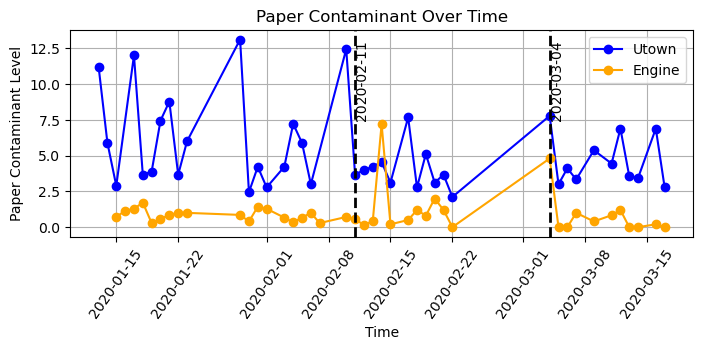

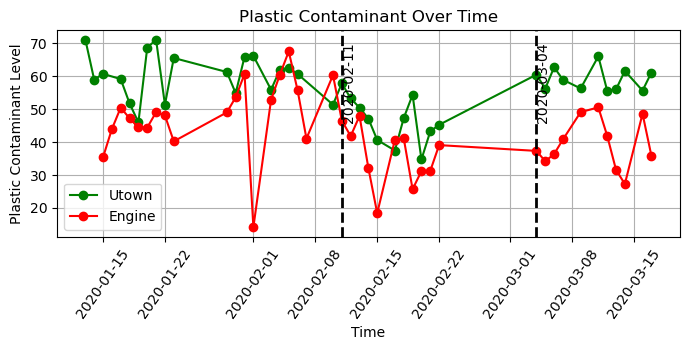

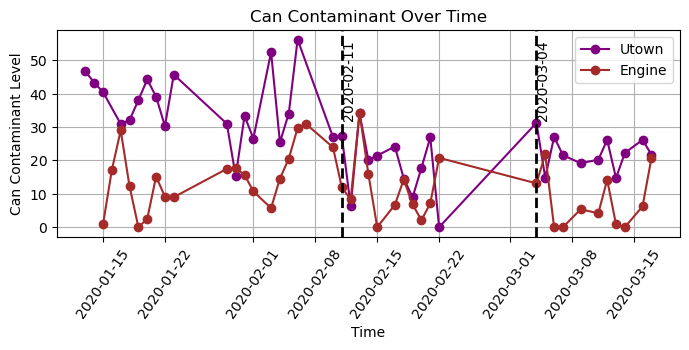

In [6]:
# Replace these column names with the actual ones from your data
time_col = 'Date'           # e.g. 'Date' or 'Week'
area_col = 'Area'           # e.g. 'Utown' / 'Engine'
paper_col = 'PaperContaminant'
plastic_col = 'PlasticContaminant'
can_col = 'CanContaminant'

# --- PLOT 1: Paper Contaminant ---
plt.figure(figsize=(7, 3))
plt.plot(df_utown[time_col], df_utown[paper_col], color='blue', marker='o', label='Utown')
plt.plot(df_engine[time_col], df_engine[paper_col], color='orange', marker='o', label='Engine')
plt.title('Paper Contaminant Over Time')
plt.xlabel('Time')
plt.ylabel('Paper Contaminant Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Add vertical lines for phase starts
plt.axvline(pd.to_datetime(phase2_start), color='black', linestyle='--', linewidth=2, label='Phase 2 Start')
plt.axvline(pd.to_datetime(phase3_start), color='black', linestyle='--', linewidth=2, label='Phase 3 Start')
plt.text(pd.to_datetime(phase2_start), plt.ylim()[1]*0.95, f'{phase2_start.date()}', rotation=90, color='black', va='top')
plt.text(pd.to_datetime(phase3_start), plt.ylim()[1]*0.95, f'{phase3_start.date()}', rotation=90, color='black', va='top')

plt.xticks(rotation=55)
plt.show()

# --- PLOT 2: Plastic Contaminant ---
plt.figure(figsize=(7, 3))
plt.plot(df_utown[time_col], df_utown[plastic_col], color='green', marker='o', label='Utown')
plt.plot(df_engine[time_col], df_engine[plastic_col], color='red', marker='o', label='Engine')
plt.title('Plastic Contaminant Over Time')
plt.xlabel('Time')
plt.ylabel('Plastic Contaminant Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Add vertical lines for phase starts
plt.axvline(pd.to_datetime(phase2_start), color='black', linestyle='--', linewidth=2, label='Phase 2 Start')
plt.axvline(pd.to_datetime(phase3_start), color='black', linestyle='--', linewidth=2, label='Phase 3 Start')

plt.text(pd.to_datetime(phase2_start), plt.ylim()[1]*0.95, f'{phase2_start.date()}', rotation=90, color='black', va='top')
plt.text(pd.to_datetime(phase3_start), plt.ylim()[1]*0.95, f'{phase3_start.date()}', rotation=90, color='black', va='top')

plt.xticks(rotation=55)
plt.show()

# --- PLOT 3: Can Contaminant ---
plt.figure(figsize=(7, 3))
plt.plot(df_utown[time_col], df_utown[can_col], color='purple', marker='o', label='Utown')
plt.plot(df_engine[time_col], df_engine[can_col], color='brown', marker='o', label='Engine')
plt.title('Can Contaminant Over Time')
plt.xlabel('Time')
plt.ylabel('Can Contaminant Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Add vertical lines for phase starts
plt.axvline(pd.to_datetime(phase2_start), color='black', linestyle='--', linewidth=2, label='Phase 2 Start')
plt.axvline(pd.to_datetime(phase3_start), color='black', linestyle='--', linewidth=2, label='Phase 3 Start')
plt.text(pd.to_datetime(phase2_start), plt.ylim()[1]*0.95, f'{phase2_start.date()}', rotation=90, color='black', va='top')
plt.text(pd.to_datetime(phase3_start), plt.ylim()[1]*0.95, f'{phase3_start.date()}', rotation=90, color='black', va='top')

plt.xticks(rotation=55)
plt.show()

#### Using a line of best fit 

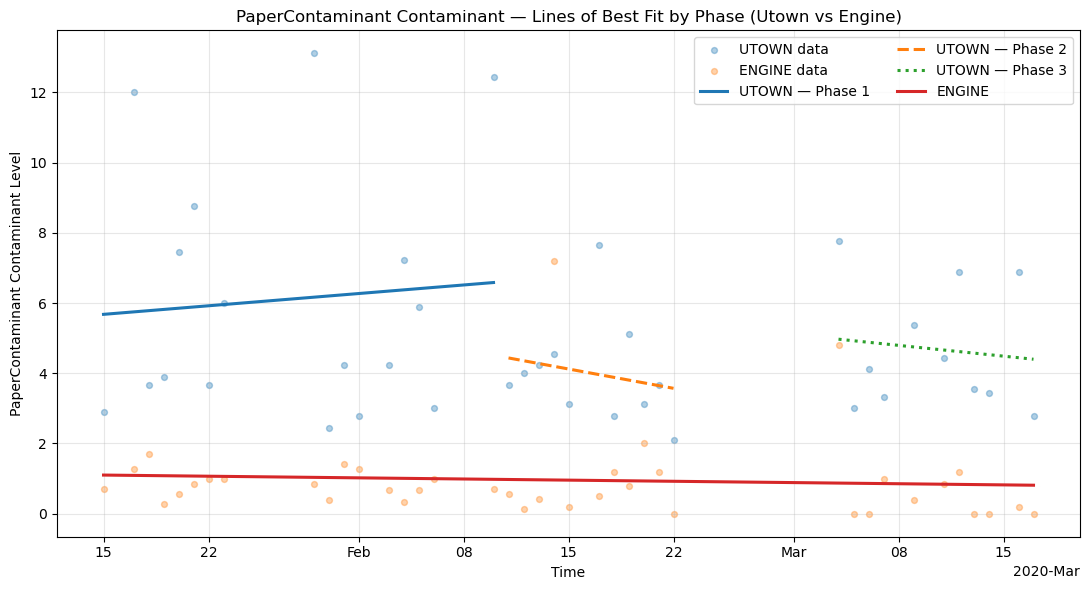

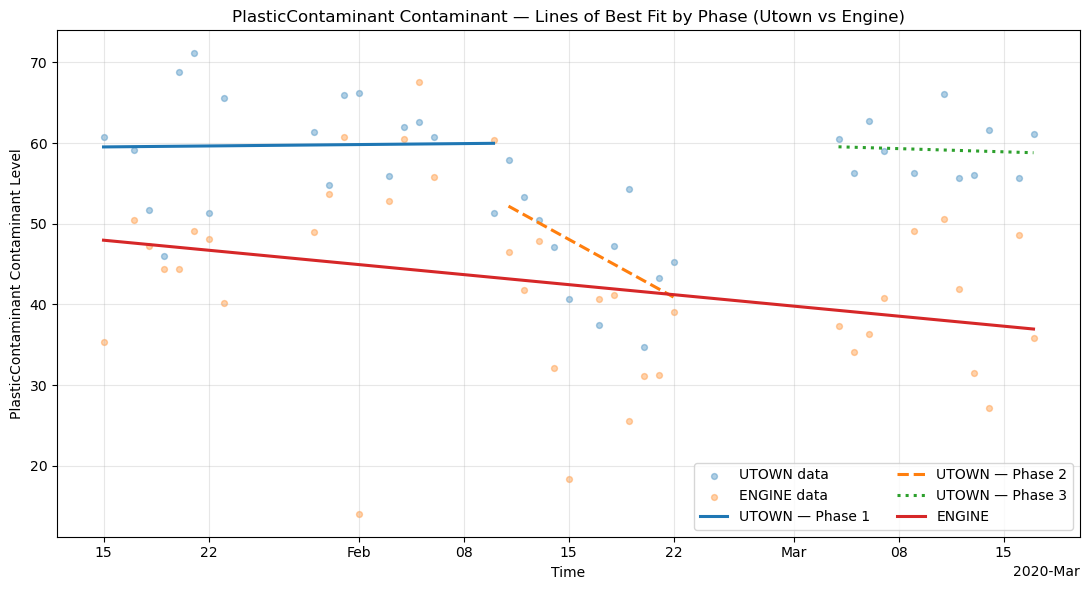

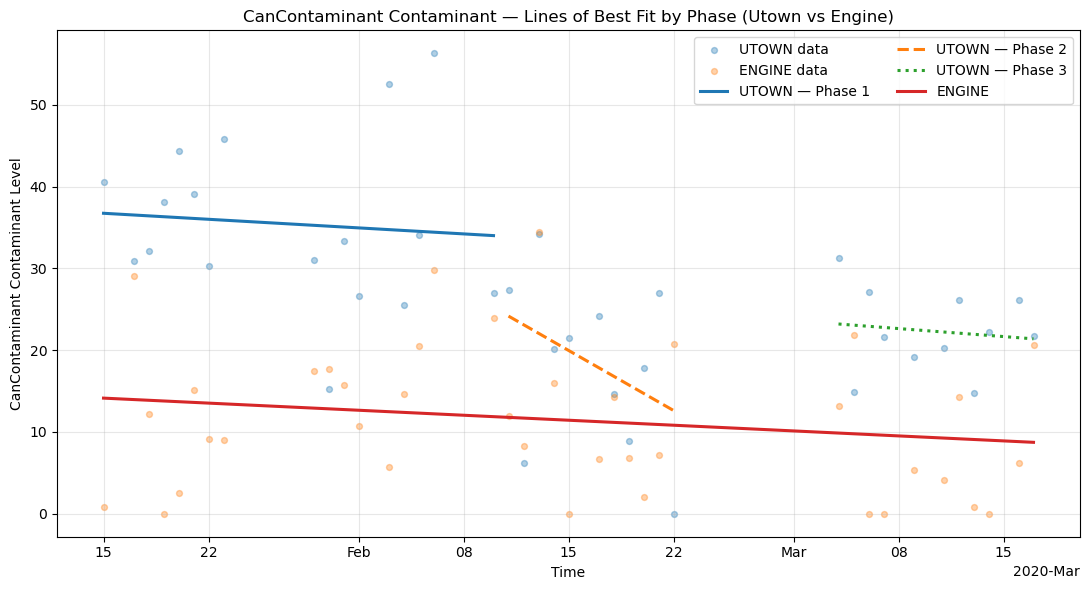

In [7]:
time_col   = 'Date'      # e.g., 'Date'
area_col   = 'Area'      # values like 'Utown' and 'Engine'
phase_col  = 'FirstTrialPhase'     # numeric or string phases (1,2,3)
contaminants = ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']  # columns for contaminants
areas = ['UTOWN', 'ENGINE']
phases = [1, 2, 3]       # if your data stores phases as strings, set ['1','2','3']

# Numeric time for regression: days since first timestamp
t0 = df_cleaned[time_col].min()
df_cleaned['_t_num'] = (df_cleaned[time_col] - t0).dt.total_seconds() / (24*3600)  # days as float

# Color by area, linestyle by phase
area_colors = {'Utown': 'tab:blue', 'Engine': 'tab:orange'}
phase_styles = {1: '-', 2: '--', 3: ':'}

# Helper: fit a simple linear regression (y = a*x + b) using numpy.polyfit
def fit_line(x, y):
    # returns slope a, intercept b
    a, b = np.polyfit(x, y, 1)
    return a, b

# Loop over contaminants and create one figure per contaminant
for cont in contaminants:
    plt.figure(figsize=(11, 6))

    # Scatter points (light) for context
    for area in areas:
        mask_area = df_cleaned[area_col] == area
        plt.scatter(
            df_cleaned.loc[mask_area, time_col],
            df_cleaned.loc[mask_area, cont],
            s=18, alpha=0.35, label=f'{area} data',
            color=area_colors.get(area, None)
        )

    # Fit and draw best-fit lines per (area, phase)
    for area in areas:
        if area == 'UTOWN':
            for ph in phases:
                mask = (df_cleaned[area_col] == area) & (df_cleaned[phase_col] == ph)
                sub = df_cleaned.loc[mask, [time_col, '_t_num', cont]].dropna()

                # Need at least 2 points to fit a line
                if len(sub) < 2:
                    continue

                x = sub['_t_num'].to_numpy()
                y = sub[cont].to_numpy()

                # Fit line
                a, b = fit_line(x, y)

                # Create x-range only ver the time span of this subset
                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = a * x_fit + b

                # Convert x_fit back to datetime for plotting
                t_fit = pd.to_datetime(t0 + pd.to_timedelta(x_fit, unit='D'))

                # Plot the fitted line
                label = f'{area} — Phase {ph}'
                plt.plot(
                    t_fit, y_fit,
                    color=area_colors.get(area, None),
                    linestyle=phase_styles.get(ph, '-.'),
                    linewidth=2.2,
                    label=label
                )
        elif area == 'ENGINE':
            mask = (df_cleaned[area_col] == area)
            sub = df_cleaned.loc[mask, [time_col, '_t_num', cont]].dropna()

            # Need at least 2 points to fit a line
            if len(sub) < 2:
                continue

            x = sub['_t_num'].to_numpy()
            y = sub[cont].to_numpy()

            # Fit line
            a, b = fit_line(x, y)

            # Create x-range only ver the time span of this subset
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = a * x_fit + b

            # Convert x_fit back to datetime for plotting
            t_fit = pd.to_datetime(t0 + pd.to_timedelta(x_fit, unit='D'))

            # Plot the fitted line
            label = f'{area}'
            plt.plot(
                t_fit, y_fit,
                color=area_colors.get(area, None),
                linestyle= '-',
                linewidth=2.2,
                label=label
            )

    # Formatting
    plt.title(f'{cont} Contaminant — Lines of Best Fit by Phase (Utown vs Engine)')
    plt.xlabel('Time')
    plt.ylabel(f'{cont} Contaminant Level')
    plt.grid(True, alpha=0.3)

    # Deduplicate legend labels (scatter + lines) while keeping order
    handles, labels = plt.gca().get_legend_handles_labels()
    seen = set()
    new_handles, new_labels = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            new_handles.append(h); new_labels.append(l); seen.add(l)
    plt.legend(new_handles, new_labels, ncol=2, frameon=True)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.tight_layout()
    plt.show()

## Parallel Trends Assumption
We visually inspect the graph earlier to see that they follow a similar parallel trend
BUT lets formally test this by checking the pre-intervention trends
- We do this by comparing the pre-treatment coefficients using the Statistical Test for Pre-Treatment Trend Differences

In [8]:
phase_1_df_all = df_cleaned.loc[df_cleaned['FirstTrialPhase'] == 1].copy()

phase_1_df_all['Day'] = phase_1_df_all.groupby(by=['Area']).cumcount() + 1

phase_1_df_parallel_trends = phase_1_df_all.copy()

phase_1_df_parallel_trends['treatment'] = phase_1_df_parallel_trends['Area'].replace({
    'ENGINE' : 0,
    'UTOWN' : 1
})

phase_1_df_parallel_trends['time_treatment'] = phase_1_df_parallel_trends['Day'] * phase_1_df_parallel_trends['treatment']

model = smf.ols("PaperContaminant ~ Day + time_treatment", data=phase_1_df_parallel_trends).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       PaperContaminant   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     11.53
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           0.000180
Time:                        21:48:09   Log-Likelihood:                -82.218
No. Observations:                  34   AIC:                             170.4
Df Residuals:                      31   BIC:                             175.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.4398      1.020      3.

/var/folders/07/c85cb0wx64dctzstjkd9gmxc0000gn/T/ipykernel_11455/961393727.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phase_1_df_parallel_trends['treatment'] = phase_1_df_parallel_trends['Area'].replace({


In [9]:
phase_1_df_parallel_trends = phase_1_df_all.copy()

phase_1_df_parallel_trends['treatment'] = phase_1_df_parallel_trends['Area'].replace({
    'ENGINE' : 0,
    'UTOWN' : 1
})

phase_1_df_parallel_trends['time_treatment'] = phase_1_df_parallel_trends['Day'] * phase_1_df_parallel_trends['treatment']

model = smf.ols("PlasticContaminant ~ Day + time_treatment", data=phase_1_df_parallel_trends).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     PlasticContaminant   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     3.098
Date:                Sat, 18 Oct 2025   Prob (F-statistic):             0.0594
Time:                        21:48:09   Log-Likelihood:                -126.64
No. Observations:                  34   AIC:                             259.3
Df Residuals:                      31   BIC:                             263.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         49.5286      3.769     13.

/var/folders/07/c85cb0wx64dctzstjkd9gmxc0000gn/T/ipykernel_11455/3207696804.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phase_1_df_parallel_trends['treatment'] = phase_1_df_parallel_trends['Area'].replace({


In [10]:
phase_1_df_parallel_trends = phase_1_df_all.copy()

phase_1_df_parallel_trends['treatment'] = phase_1_df_parallel_trends['Area'].replace({
    'ENGINE' : 0,
    'UTOWN' : 1
})

phase_1_df_parallel_trends['time_treatment'] = phase_1_df_parallel_trends['Day'] * phase_1_df_parallel_trends['treatment']

model = smf.ols("CanContaminant ~ Day + time_treatment", data=phase_1_df_parallel_trends).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         CanContaminant   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     9.239
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           0.000713
Time:                        21:48:09   Log-Likelihood:                -130.80
No. Observations:                  34   AIC:                             267.6
Df Residuals:                      31   BIC:                             272.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         21.0625      4.259      4.

/var/folders/07/c85cb0wx64dctzstjkd9gmxc0000gn/T/ipykernel_11455/1830704964.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phase_1_df_parallel_trends['treatment'] = phase_1_df_parallel_trends['Area'].replace({


## Hypothesis testing
So we set up 2 hypothesis tests:

1st Hypothesis test
- H0: shaped openings have no effect on contamination rates of paper, plastic and can
- H1: shaped openings reduces contamination rates of paper, plastic and can (this will be a one tailed with significance level 0.05)

2nd Hypothesis test
- H0: informational banners have no effect on contamination rates of paper, plastic and can
- H1: informational banners reduces contamination rates of paper, plastic and can (this will be a one tailed with significance level 0.05)

In [11]:
contaminant_list = ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']

In [12]:
## DID Regression as per lecture slides for phase 1 vs phase 2
df_for_did_opening = df_cleaned.loc[(df_cleaned['FirstTrialPhase'] == 1) | (df_cleaned['FirstTrialPhase'] ==  2)].copy()

# set 1 if its treatment, 0 if control
df_for_did_opening['treatment'] = df_for_did_opening['Area'].replace({
    'ENGINE' : 0,
    'UTOWN' : 1
})
#df_for_did_opening['post'] = df_for_did_opening

# set 1 if its trial phase 2 (>= 2020-02-11), 0 if its trail phase 1 aka pre-treatment
df_for_did_opening['post'] = df_for_did_opening['FirstTrialPhase'].replace({
    1.0 : 0,
    2.0 : 1
})
df_for_did_opening['treatment_post'] = df_for_did_opening['post'] * df_for_did_opening['treatment']

# run the DID regression
for contaminant in contaminant_list:
    model = smf.ols(f'{contaminant} ~ treatment + post + treatment_post', data = df_for_did_opening).fit()
    #print(model.summary())
    print(f"{contaminant}")
    for var in model.params.index:
        if var == 'Intercept':
            coef = model.params[var]
            pval = model.pvalues[var]
            #print(f" {coef:.4f} (p = {pval:.4f})", end='')
            print(f" {coef:.4f}", end='')
        else:
            coef = model.params[var]
            pval = model.pvalues[var]
            sign = '+' if coef >= 0 else '-'
            #print(f" {coef:.4f}{var} (p = {pval:.4f})", end='')
            print(f" {sign} {abs(coef):.4f}{var}", end='')
    print(f" + \u03B5")
    print("\n")

PaperContaminant
 0.8695 + 5.2286treatment + 0.4253post - 2.5234treatment_post + ε


PlasticContaminant
 49.0448 + 10.6883treatment - 13.0869post - 0.1387treatment_post + ε


CanContaminant
 13.7729 + 21.6928treatment - 2.0983post - 15.0244treatment_post + ε




/var/folders/07/c85cb0wx64dctzstjkd9gmxc0000gn/T/ipykernel_11455/2675694695.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_for_did_opening['treatment'] = df_for_did_opening['Area'].replace({


In [13]:
model = smf.ols(f'PaperContaminant ~ treatment + post + treatment_post', data = df_for_did_opening).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       PaperContaminant   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     18.19
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           3.37e-08
Time:                        21:48:09   Log-Likelihood:                -123.38
No. Observations:                  56   AIC:                             254.8
Df Residuals:                      52   BIC:                             262.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.8695      0.551      1.

In [14]:
model = smf.ols(f'PlasticContaminant ~ treatment + post + treatment_post', data = df_for_did_opening).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     PlasticContaminant   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     15.06
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           3.53e-07
Time:                        21:48:09   Log-Likelihood:                -202.17
No. Observations:                  56   AIC:                             412.3
Df Residuals:                      52   BIC:                             420.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         49.0448      2.252     21.

In [15]:
model = smf.ols(f'CanContaminant ~ treatment + post + treatment_post', data = df_for_did_opening).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         CanContaminant   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     19.20
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           1.64e-08
Time:                        21:48:09   Log-Likelihood:                -204.92
No. Observations:                  56   AIC:                             417.8
Df Residuals:                      52   BIC:                             425.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         13.7729      2.365      5.

In [16]:
## DID Regression as per lecture slides for phase 1 vs phase 3 (naive)
df_for_did_banners = df_cleaned.loc[(df_cleaned['FirstTrialPhase'] == 1) | (df_cleaned['FirstTrialPhase'] ==  3)].copy()

# set 1 if its treatment, 0 if control
df_for_did_banners['treatment'] = df_for_did_banners['Area'].replace({
    'ENGINE' : 0,
    'UTOWN' : 1
})
#df_for_did_banners['post'] = df_for_did_banners

# set 1 if its trial phase 3, 0 if its trail phase 1 aka pre-treatment
df_for_did_banners['post'] = df_for_did_banners['FirstTrialPhase'].replace({
    1.0 : 0,
    3.0 : 1
})
df_for_did_banners['treatment_post'] = df_for_did_banners['post'] * df_for_did_banners['treatment']

# run the DID regression
for contaminant in contaminant_list:
    model = smf.ols(f'{contaminant} ~ treatment + post + treatment_post', data = df_for_did_banners).fit()
    #print(model.summary())
    print(f"{contaminant}")
    for var in model.params.index:
        if var == 'Intercept':
            coef = model.params[var]
            pval = model.pvalues[var]
            #print(f" {coef:.4f} (p = {pval:.4f})", end='')
            print(f" {coef:.4f}", end='')
        else:
            coef = model.params[var]
            pval = model.pvalues[var]
            sign = '+' if coef >= 0 else '-'
            #print(f" {coef:.4f}{var} (p = {pval:.4f})", end='')
            print(f" {sign} {abs(coef):.4f}{var}", end='')
    print(f" + \u03B5")
    print("\n")

PaperContaminant
 0.8695 + 5.2286treatment - 0.1028post - 1.3046treatment_post + ε


PlasticContaminant
 49.0448 + 10.6883treatment - 9.6510post + 9.0998treatment_post + ε


CanContaminant
 13.7729 + 21.6928treatment - 5.9166post - 7.2431treatment_post + ε




/var/folders/07/c85cb0wx64dctzstjkd9gmxc0000gn/T/ipykernel_11455/2147665587.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_for_did_banners['treatment'] = df_for_did_banners['Area'].replace({


In [17]:
model = smf.ols(f'PaperContaminant ~ treatment + post + treatment_post', data = df_for_did_banners).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       PaperContaminant   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.533
Method:                 Least Squares   F-statistic:                     21.96
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           2.54e-09
Time:                        21:48:09   Log-Likelihood:                -122.05
No. Observations:                  56   AIC:                             252.1
Df Residuals:                      52   BIC:                             260.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.8695      0.538      1.

In [18]:
model = smf.ols(f'PlasticContaminant ~ treatment + post + treatment_post', data = df_for_did_banners).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     PlasticContaminant   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     15.70
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           2.15e-07
Time:                        21:48:09   Log-Likelihood:                -197.80
No. Observations:                  56   AIC:                             403.6
Df Residuals:                      52   BIC:                             411.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         49.0448      2.082     23.

In [19]:
model = smf.ols(f'CanContaminant ~ treatment + post + treatment_post', data = df_for_did_banners).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         CanContaminant   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     28.14
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           5.98e-11
Time:                        21:48:09   Log-Likelihood:                -198.42
No. Observations:                  56   AIC:                             404.8
Df Residuals:                      52   BIC:                             412.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         13.7729      2.106      6.

### Two Way Fixed Effect Regression

In [20]:
df_twfe = df_cleaned.copy()

# 2) Define the informational banner “on” indicator
#    If Phase 3 is precisely the banner period, the cleanest is:
df_twfe["post"] = (df_twfe["FirstTrialPhase"] == 3).astype(int)
df_twfe["treatment"] = (df_twfe["Area"].str.upper() == "UTOWN").astype(int)

# 3) DiD interaction
df_twfe["treatment_post"] = df_twfe["treatment"] * df_twfe["post"]

# 4) Two-way fixed effects via categorical dummies:
fe_formula = "PaperContaminant ~ treatment + C(FirstTrialPhase) + treatment_post"

model = smf.ols(fe_formula, data=df_twfe).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       PaperContaminant   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     18.63
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           1.37e-10
Time:                        21:48:09   Log-Likelihood:                -168.23
No. Observations:                  78   AIC:                             346.5
Df Residuals:                      73   BIC:                             358.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [21]:
df_twfe = df_cleaned.copy()

# 2) Define the informational banner “on” indicator
#    If Phase 3 is precisely the banner period, the cleanest is:
df_twfe["post"] = (df_twfe["FirstTrialPhase"] == 3).astype(int)
df_twfe["treatment"] = (df_twfe["Area"].str.upper() == "UTOWN").astype(int)

# 3) DiD interaction
df_twfe["treatment_post"] = df_twfe["treatment"] * df_twfe["post"]

# 4) Two-way fixed effects via categorical dummies:
fe_formula = "PlasticContaminant ~ treatment + C(FirstTrialPhase) + treatment_post"

model = smf.ols(fe_formula, data=df_twfe).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     PlasticContaminant   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     21.30
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           1.13e-11
Time:                        21:48:09   Log-Likelihood:                -274.33
No. Observations:                  78   AIC:                             558.7
Df Residuals:                      73   BIC:                             570.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [22]:
df_twfe = df_cleaned.copy()

# 2) Define the informational banner “on” indicator
#    If Phase 3 is precisely the banner period, the cleanest is:
df_twfe["post"] = (df_twfe["FirstTrialPhase"] == 3).astype(int)
df_twfe["treatment"] = (df_twfe["Area"].str.upper() == "UTOWN").astype(int)

# 3) DiD interaction
df_twfe["treatment_post"] = df_twfe["treatment"] * df_twfe["post"]

# 4) Two-way fixed effects via categorical dummies:
fe_formula = "CanContaminant ~ treatment + C(FirstTrialPhase) + treatment_post"

model = smf.ols(fe_formula, data=df_twfe).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         CanContaminant   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     17.57
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           3.85e-10
Time:                        21:48:09   Log-Likelihood:                -284.02
No. Observations:                  78   AIC:                             578.0
Df Residuals:                      73   BIC:                             589.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [23]:
# run the DID TWFE regression
#var_of_interest = ['Area', 'treatment_post', 'FirstTrialPhase']
for contaminant in contaminant_list:
    fe_formula = f"{contaminant} ~  treatment + C(FirstTrialPhase) + treatment_post"
    model = smf.ols(fe_formula, data=df_twfe).fit() 

    print(f"{contaminant}")
    for var in model.params.index:
        if var == 'Intercept':
            coef = model.params[var]
            pval = model.pvalues[var]
            #print(f" {coef:.4f} (p = {pval:.4f})", end='')
            print(f" {coef:.4f}", end='')
        else:
            coef = model.params[var]
            pval = model.pvalues[var]
            sign = '+' if coef >= 0 else '-'
            #print(f" {coef:.4f}{var} (p = {pval:.4f})", end='')
            print(f" {sign} {abs(coef):.4f}{var}", end='')
    print(f" + \u03B5")
    print("\n")

PaperContaminant
 1.3651 - 0.8364C(FirstTrialPhase)[T.2.0] - 0.5985C(FirstTrialPhase)[T.3.0] + 4.2372treatment - 0.3133treatment_post + ε


PlasticContaminant
 49.0720 - 13.1562C(FirstTrialPhase)[T.2.0] - 9.6782C(FirstTrialPhase)[T.3.0] + 10.6338treatment + 9.1543treatment_post + ε


CanContaminant
 16.7241 - 9.6105C(FirstTrialPhase)[T.2.0] - 8.8678C(FirstTrialPhase)[T.3.0] + 15.7903treatment - 1.3407treatment_post + ε


